# Load ICPSR Data

This notebook loads the ICPSR TSV file into a pandas DataFrame named `df`.

In [5]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# Build path relative to this notebook's folder
file_path = Path("DS0001") / "38304-0001-Data.tsv"

df = pd.read_csv(file_path, sep="\t")

print(f"Loaded {len(df):,} rows and {df.shape[1]} columns")
df.head()

Loaded 1,495 rows and 234 columns


,STARTDATE,ENDDATE,STATUS,IPADDRESS,PROGRESS,DURATION__IN_SECONDS_,TIME,TIME_FLAG,FINISHED,RECORDEDDATE,...,QOL,PH,PSY,SOCREL,ENV,ADAMSPSYCH_MEAN,ADAMSEMO_MEAN,ADAMSSOC_MEAN,ADAMSSPIR_MEAN,ADAMSINT_MEAN
0,27-MAY-2020 08:01:31,27-MAY-2020 08:12:32,0,*******,100,661,11.016666,0,1,27-MAY-2020 08:12:32,...,100.0,92.85713958741,83.333336,83.333336,100.000,4.333333,3.666667,4.000000,3.500000,4.500000
1,27-MAY-2020 07:58:38,27-MAY-2020 08:13:07,0,*******,100,869,14.483334,0,1,27-MAY-2020 08:13:07,...,87.5,71.4285736084,79.166664,75.000000,100.000,3.833333,3.833333,3.500000,4.000000,3.833333
2,27-MAY-2020 07:59:18,27-MAY-2020 08:13:30,0,*******,100,852,14.200000,0,1,27-MAY-2020 08:13:30,...,87.5,92.85713958741,83.333336,100.000000,100.000,4.166667,4.166667,4.166667,4.333333,4.166667
3,27-MAY-2020 07:58:41,27-MAY-2020 08:14:22,0,*******,100,941,15.683333,0,1,27-MAY-2020 08:14:23,...,87.5,85.7142868042,91.666664,75.000000,90.625,4.500000,4.500000,3.333333,4.333333,4.833333
4,27-MAY-2020 08:02:02,27-MAY-2020 08:14:36,0,*******,100,754,12.566667,0,1,27-MAY-2020 08:14:38,...,37.5,25,54.166668,16.666666,34.375,3.333333,4.166667,3.666667,3.000000,3.333333


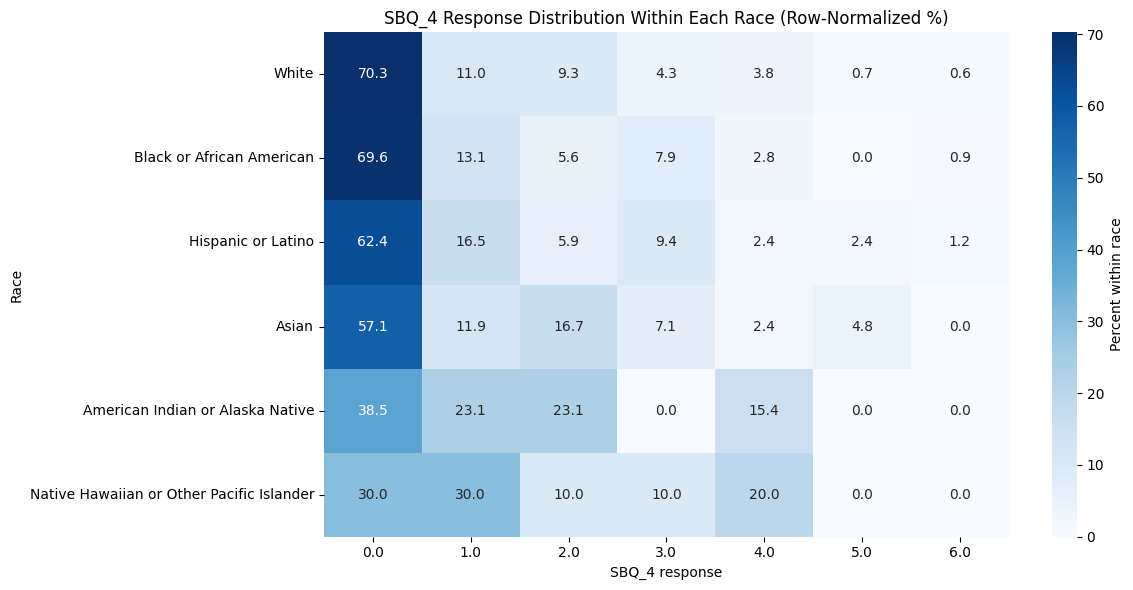

In [18]:

# Map race codes to labels provided
race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}

plot_df = df[["RACE", "SBQ_4"]].copy()
plot_df["RACE"] = pd.to_numeric(plot_df["RACE"], errors="coerce")
plot_df["SBQ_4"] = pd.to_numeric(plot_df["SBQ_4"], errors="coerce")
plot_df = plot_df.dropna(subset=["RACE", "SBQ_4"])
plot_df = plot_df[plot_df["RACE"].isin(race_map.keys())].copy()
plot_df["RACE_LABEL"] = plot_df["RACE"].astype(int).map(race_map)

# One subplot per SBQ_4 category, with race counts in each subplot
race_order = [race_map[k] for k in sorted(race_map.keys())]
sbq_categories = sorted(plot_df["SBQ_4"].dropna().unique())

n_cats = len(sbq_categories)
ncols = 3
# Build a race x SBQ_4 table
ct = pd.crosstab(plot_df["RACE_LABEL"], plot_df["SBQ_4"])
ct = ct.reindex(index=race_order, fill_value=0)

# Normalize by row so each race row sums to 100%
heatmap_pct = ct.div(ct.sum(axis=1), axis=0).mul(100)

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_pct,
    cmap="Blues",
    annot=True,
    fmt=".1f",
    cbar_kws={"label": "Percent within race"},
)
plt.title("SBQ_4 Response Distribution Within Each Race (Row-Normalized %)")
plt.xlabel("SBQ_4 response")
plt.ylabel("Race")
plt.tight_layout()
plt.show()

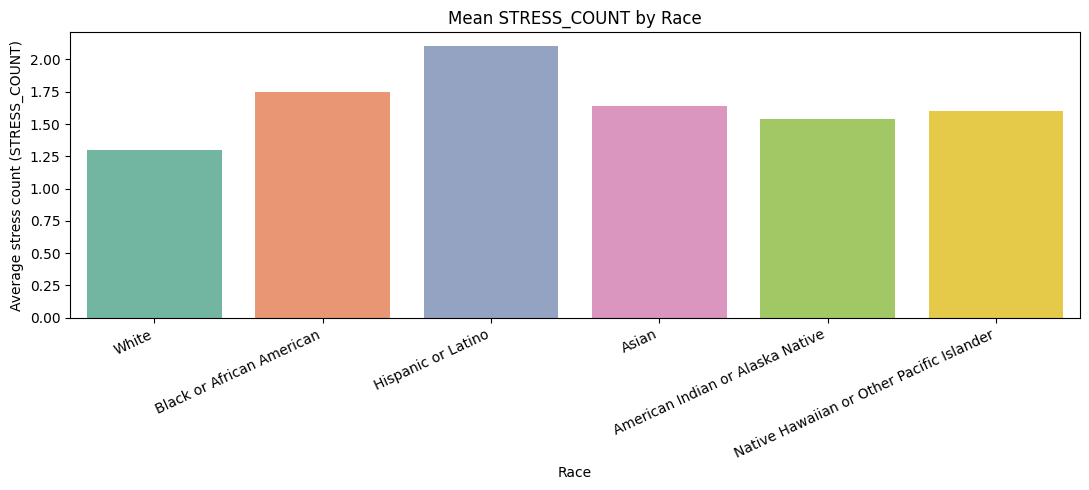

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average STRESS_COUNT by race (labeled categories)
race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}

stress_df = df[["RACE", "STRESS_COUNT"]].copy()
stress_df["RACE"] = pd.to_numeric(stress_df["RACE"], errors="coerce")
stress_df["STRESS_COUNT"] = pd.to_numeric(stress_df["STRESS_COUNT"], errors="coerce")
stress_df = stress_df.dropna(subset=["RACE", "STRESS_COUNT"])
stress_df = stress_df[stress_df["RACE"].isin(race_map.keys())].copy()
stress_df["RACE_LABEL"] = stress_df["RACE"].astype(int).map(race_map)

avg_by_race = (
    stress_df.groupby("RACE_LABEL", observed=True)["STRESS_COUNT"]
    .mean()
    .reindex([race_map[k] for k in sorted(race_map.keys())])
    .reset_index(name="Mean_STRESS_COUNT")
)

plt.figure(figsize=(11, 5))
sns.barplot(data=avg_by_race, x="RACE_LABEL", y="Mean_STRESS_COUNT", hue="RACE_LABEL", legend=False, palette="Set2")
plt.title("Mean STRESS_COUNT by Race")
plt.xlabel("Race")
plt.ylabel("Average stress count (STRESS_COUNT)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

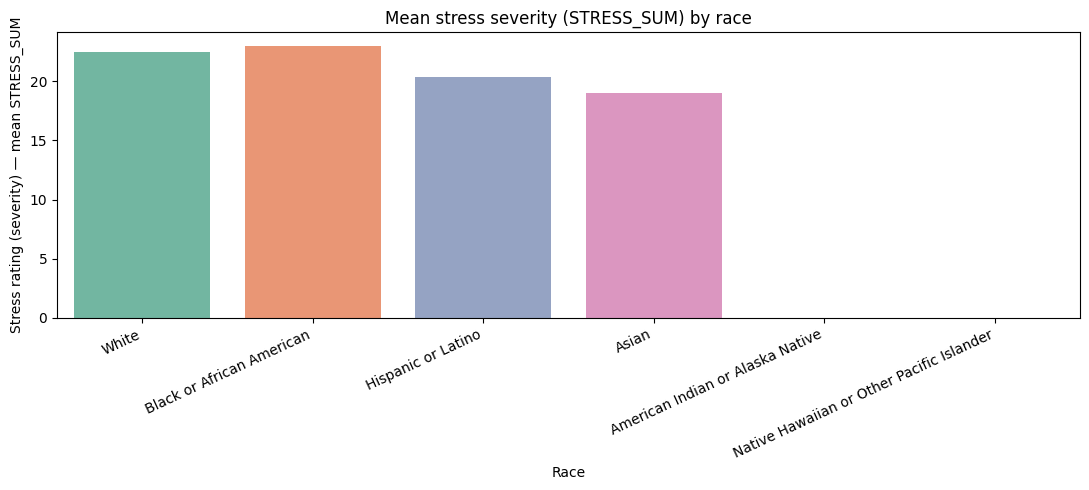

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mean stress severity (STRESS_SUM) by race — sum of stress item ratings
race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}

severity_df = df[["RACE", "STRESS_SUM"]].copy()
severity_df["RACE"] = pd.to_numeric(severity_df["RACE"], errors="coerce")
severity_df["STRESS_SUM"] = pd.to_numeric(severity_df["STRESS_SUM"], errors="coerce")
severity_df = severity_df.dropna(subset=["RACE", "STRESS_SUM"])
severity_df = severity_df[severity_df["RACE"].isin(race_map.keys())].copy()
severity_df["RACE_LABEL"] = severity_df["RACE"].astype(int).map(race_map)

avg_severity = (
    severity_df.groupby("RACE_LABEL", observed=True)["STRESS_SUM"]
    .mean()
    .reindex([race_map[k] for k in sorted(race_map.keys())])
    .reset_index(name="Mean_STRESS_SUM")
)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=avg_severity,
    x="RACE_LABEL",
    y="Mean_STRESS_SUM",
    hue="RACE_LABEL",
    legend=False,
    palette="Set2",
)
plt.title("Mean stress severity (STRESS_SUM) by race")
plt.xlabel("Race")
plt.ylabel("Stress rating (severity) — mean STRESS_SUM")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

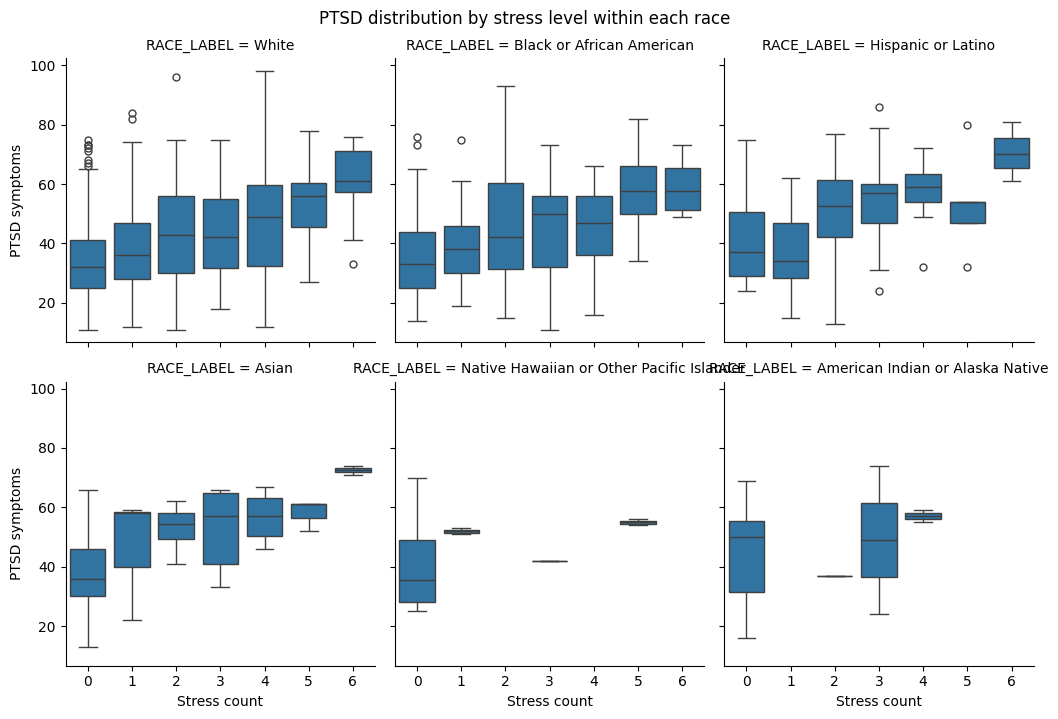

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# PTSD proxy: MISSSF_TOTAL (Mississippi PTSD-related scale total). No column named "PTSD" in file.
race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}

line_df = df[["RACE", "STRESS_COUNT", "MISSSF_TOTAL"]].copy()
line_df["RACE"] = pd.to_numeric(line_df["RACE"], errors="coerce")
for col in ["STRESS_COUNT", "MISSSF_TOTAL"]:
    line_df[col] = pd.to_numeric(line_df[col], errors="coerce")
line_df = line_df[line_df["RACE"].isin(race_map.keys())].copy()
line_df["RACE_LABEL"] = line_df["RACE"].astype(int).map(race_map)
line_df = line_df.dropna(subset=["STRESS_COUNT", "MISSSF_TOTAL"])

# plt.figure(figsize=(10, 5))
# sns.lineplot(
#     data=line_df,
#     x="STRESS_COUNT",
#     y="MISSSF_TOTAL",
#     hue="RACE_LABEL",
#     hue_order=[race_map[k] for k in sorted(race_map.keys())],
#     marker="o",
#     err_style="band",
# )
# plt.xlabel("Stress (low → high, STRESS_COUNT)")
# plt.ylabel("PTSD symptoms (MISSSF_TOTAL, mean ± CI)")
# plt.title("Mean PTSD symptoms by stress level and race")
# plt.legend(title="Race", bbox_to_anchor=(1.02, 1), loc="upper left")
# plt.tight_layout()
# plt.show()

g = sns.catplot(
    data=line_df,
    x="STRESS_COUNT",
    y="MISSSF_TOTAL",
    col="RACE_LABEL",
    col_wrap=3,
    kind="box",
    sharey=True,
    height=3.5,
)

g.set_axis_labels("Stress count", "PTSD symptoms")
g.fig.suptitle("PTSD distribution by stress level within each race", y=1.02)
plt.show()

**Analysis**: Across all racial groups, PTSD symptoms increase as the number of reported stressors rises, with median PTSD scores shifting upward at higher stress levels. This pattern is consistent for White, Black, Hispanic/Latino, and Asian veterans, indicating a robust positive relationship between stress exposure and psychological distress. However, the strength and consistency of this increase vary slightly across groups, with some showing more gradual or variable changes than others. Additionally, smaller groups, such as Native Hawaiian or Other Pacific Islander and American Indian or Alaska Native veterans, display less stable patterns, likely due to limited sample sizes. Overall, the results suggest that while stress is a strong predictor of PTSD across all groups, the distribution and variability of responses differ somewhat by race.

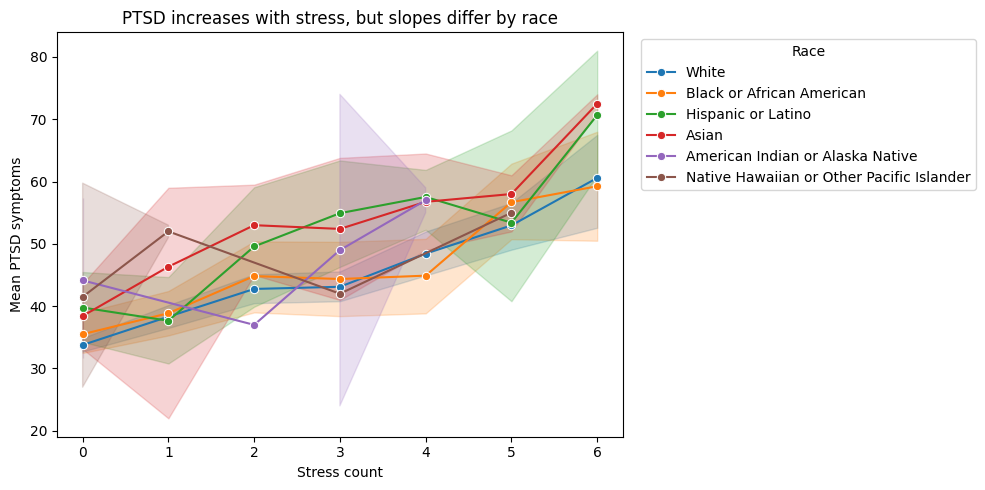

In [33]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=line_df,
    x="STRESS_COUNT",
    y="MISSSF_TOTAL",
    hue="RACE_LABEL",
    hue_order=[race_map[k] for k in sorted(race_map.keys())],
    estimator="mean",      # ensures you're plotting mean
    errorbar=("ci", 95),   # confidence intervals
    marker="o",
)

plt.xlabel("Stress count")
plt.ylabel("Mean PTSD symptoms")
plt.title("PTSD increases with stress, but slopes differ by race")
plt.legend(title="Race", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

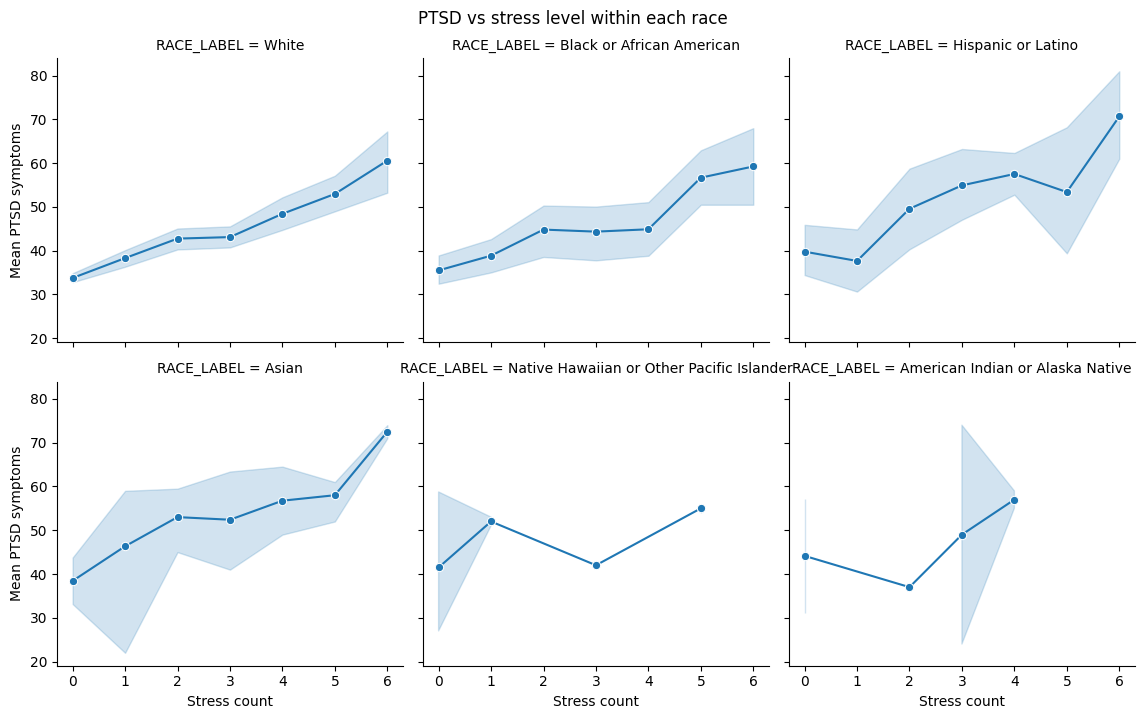

In [29]:
g = sns.relplot(
    data=line_df,
    x="STRESS_COUNT",
    y="MISSSF_TOTAL",
    col="RACE_LABEL",                 # one subplot per race
    col_wrap=3,                       # layout (3 per row)
    kind="line",
    estimator="mean",
    errorbar=("ci", 95),
    marker="o",
    height=3.5,
    aspect=1.1,
)

g.set_axis_labels("Stress count", "Mean PTSD symptoms")
g.fig.suptitle("PTSD vs stress level within each race", y=1.02)

plt.show()

**Analysis**: Across all racial groups, mean PTSD symptoms increase as the number of reported stressors rises, indicating a consistent positive relationship between stress exposure and psychological distress. However, the rate of increase varies across groups, with Hispanic/Latino and Asian veterans showing steeper increases in PTSD at higher stress levels compared to White and Black veterans, who exhibit more gradual trends. Additionally, some groups display non-linear patterns, suggesting that the impact of stress may intensify at higher levels of exposure. Confidence intervals are wider for smaller groups, such as Native Hawaiian or Other Pacific Islander and American Indian or Alaska Native veterans, indicating greater uncertainty in these estimates. Overall, while stress is a strong predictor of PTSD for all groups, the strength and stability of this relationship differ across racial groups.

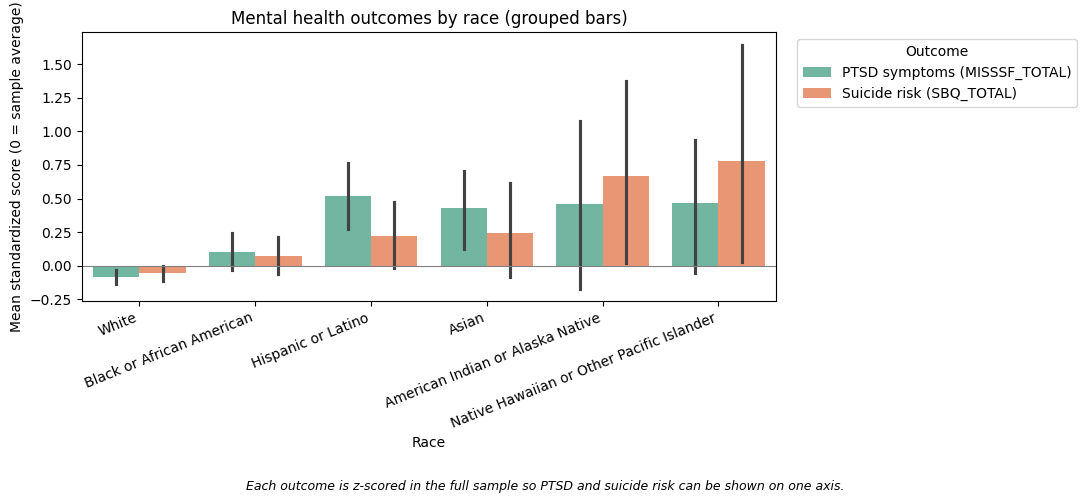

In [ ]:
# Grouped bars: mental health outcomes by race (PTSD proxy + suicide risk).
# Raw scales differ (MISSSF_TOTAL vs SBQ_TOTAL), so each measure is z-scored in the
# full sample before averaging — bars = mean z within race (comparable across outcomes).
race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}
race_order = [race_map[k] for k in sorted(race_map.keys())]

ob = df[["RACE", "MISSSF_TOTAL", "SBQ_TOTAL"]].copy()
ob["RACE"] = pd.to_numeric(ob["RACE"], errors="coerce")
ob["MISSSF_TOTAL"] = pd.to_numeric(ob["MISSSF_TOTAL"], errors="coerce")
ob["SBQ_TOTAL"] = pd.to_numeric(ob["SBQ_TOTAL"], errors="coerce")
ob = ob.dropna(subset=["RACE", "MISSSF_TOTAL", "SBQ_TOTAL"])
ob = ob[ob["RACE"].isin(race_map.keys())].copy()
ob["RACE_LABEL"] = ob["RACE"].astype(int).map(race_map)

ob["PTSD_z"] = (ob["MISSSF_TOTAL"] - ob["MISSSF_TOTAL"].mean()) / ob["MISSSF_TOTAL"].std()
ob["Suicide_risk_z"] = (ob["SBQ_TOTAL"] - ob["SBQ_TOTAL"].mean()) / ob["SBQ_TOTAL"].std()

long = ob.melt(
    id_vars=["RACE_LABEL"],
    value_vars=["PTSD_z", "Suicide_risk_z"],
    var_name="Outcome",
    value_name="Score_z",
)
long["Outcome"] = long["Outcome"].map(
    {"PTSD_z": "PTSD symptoms (MISSSF_TOTAL)", "Suicide_risk_z": "Suicide risk (SBQ_TOTAL)"}
)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=long,
    x="RACE_LABEL",
    y="Score_z",
    hue="Outcome",
    order=race_order,
    palette="Set2",
    errorbar=("ci", 95),
)
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Mental health outcomes by race (grouped bars)")
plt.xlabel("Race")
plt.ylabel("Mean standardized score (0 = sample average)")
plt.xticks(rotation=22, ha="right")
plt.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.figtext(
    0.5,
    0.01,
    "Each outcome is z-scored in the full sample so PTSD and suicide risk can be shown on one axis.",
    ha="center",
    fontsize=9,
    style="italic",
)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

**Method**: We selected observations with complete data on race, PTSD symptoms, and suicide risk, recoded race into six categories, and standardized both outcome variables (z-scoring across the full sample) to place them on a common scale. The data were then reshaped into long format, and the mean standardized score for each outcome was calculated within each racial group. These group means were plotted as a grouped bar chart with 95% confidence intervals.

**Analysis**: This plot shows clear differences in mental health outcomes across racial groups, though with some variability. White veterans report the lowest levels of both PTSD symptoms and suicide risk, with scores slightly below the sample average. Black or African American veterans are close to the average, with only slightly elevated PTSD and suicide risk. Hispanic or Latino veterans show notably higher PTSD symptoms but more moderate increases in suicide risk. Asian veterans also exhibit elevated PTSD and somewhat higher suicide risk, though less pronounced. The most striking pattern appears among American Indian or Alaska Native and Native Hawaiian or Other Pacific Islander veterans, who show the highest levels of both PTSD symptoms and suicide risk, with especially large increases in suicide risk. However, the wide error bars for these groups suggest greater variability and possibly smaller sample sizes. Overall, the pattern indicates that minority groups—particularly Indigenous and Pacific Islander veterans—tend to experience worse mental health outcomes compared to White veterans, though the magnitude and consistency of these differences vary across groups.

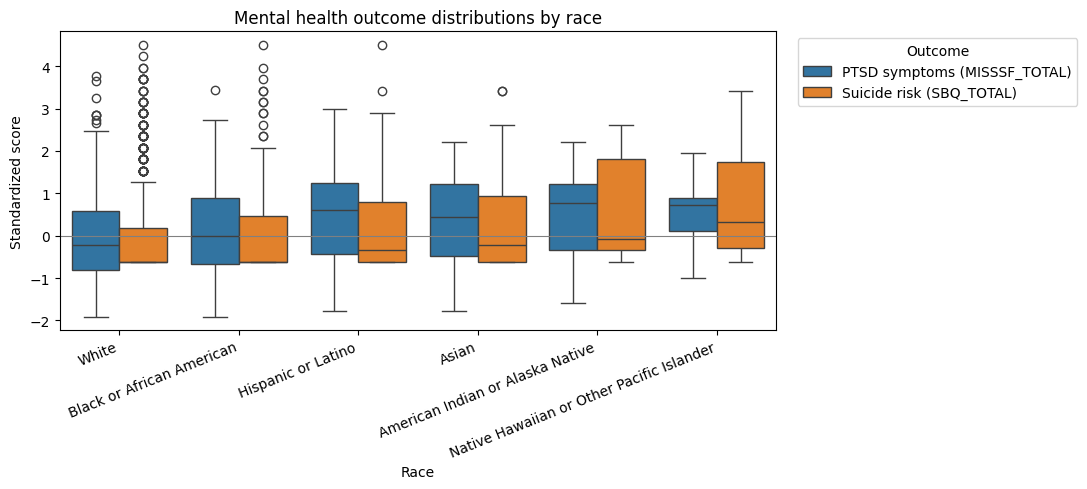

In [34]:
plt.figure(figsize=(11, 5))
sns.boxplot(
    data=long,
    x="RACE_LABEL",
    y="Score_z",
    hue="Outcome",
    order=race_order,
)
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Mental health outcome distributions by race")
plt.xlabel("Race")
plt.ylabel("Standardized score")
plt.xticks(rotation=22, ha="right")
plt.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Analysis**: Boxplot analysis shows that PTSD symptoms are generally higher among Hispanic, Asian, American Indian or Alaska Native, and Native Hawaiian or Pacific Islander participants compared to White and Black participants. Differences in suicide risk are less consistent across groups, though Native Hawaiian or Pacific Islander participants exhibit higher median values and greater variability. Substantial overlap in distributions suggests that disparities are present but not sharply separated across groups.

/Users/katherineharvey/anaconda3/envs/test/lib/python3.13/site-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


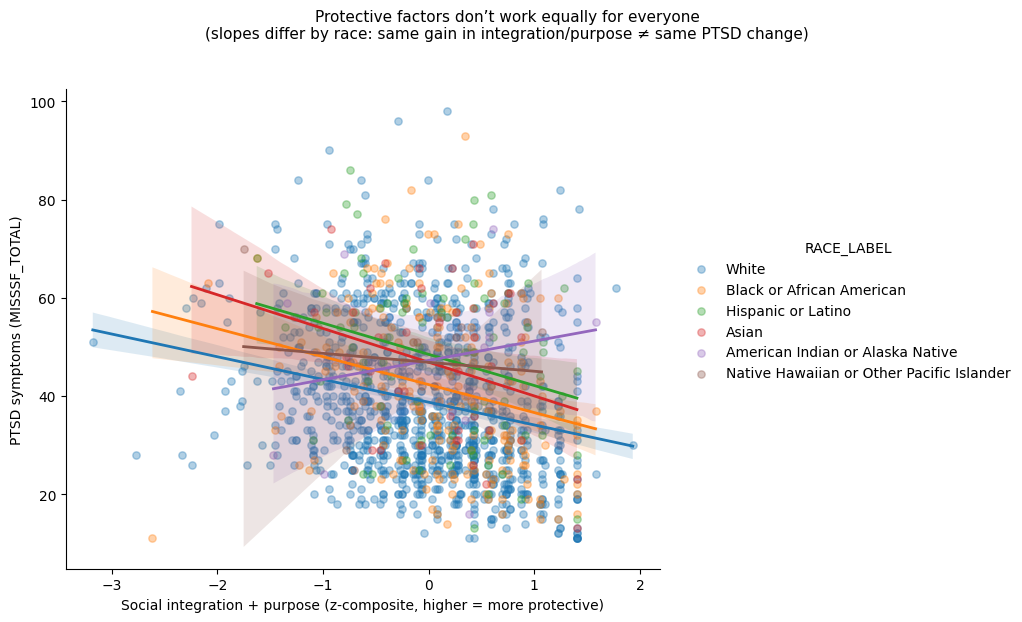

In [24]:
# Protective factors: combined social integration + purpose vs PTSD, by race.
# Composite x = mean of z-scores(SOCINT_MEAN) and z-scores(PUR_MEAN) — higher = more protective context.
# PTSD y = MISSSF_TOTAL. Separate regression lines per race highlight unequal "protection."
race_map = {
    1: "White",
    2: "Black or African American",
    3: "Hispanic or Latino",
    4: "Asian",
    5: "American Indian or Alaska Native",
    6: "Native Hawaiian or Other Pacific Islander",
}

prot = df[["RACE", "SOCINT_MEAN", "PUR_MEAN", "MISSSF_TOTAL"]].copy()
for c in ["RACE", "SOCINT_MEAN", "PUR_MEAN", "MISSSF_TOTAL"]:
    prot[c] = pd.to_numeric(prot[c], errors="coerce")
prot = prot.dropna()
prot = prot[prot["RACE"].isin(race_map.keys())].copy()
prot["RACE_LABEL"] = prot["RACE"].astype(int).map(race_map)

soc_z = (prot["SOCINT_MEAN"] - prot["SOCINT_MEAN"].mean()) / prot["SOCINT_MEAN"].std()
pur_z = (prot["PUR_MEAN"] - prot["PUR_MEAN"].mean()) / prot["PUR_MEAN"].std()
prot["integration_purpose_index"] = (soc_z + pur_z) / 2

g = sns.lmplot(
    data=prot,
    x="integration_purpose_index",
    y="MISSSF_TOTAL",
    hue="RACE_LABEL",
    hue_order=[race_map[k] for k in sorted(race_map.keys())],
    height=6,
    aspect=1.15,
    scatter_kws={"alpha": 0.35, "s": 28},
    line_kws={"linewidth": 2},
    legend_out=True,
)
g.set_axis_labels(
    "Social integration + purpose (z-composite, higher = more protective)",
    "PTSD symptoms (MISSSF_TOTAL)",
)
g.fig.suptitle(
    "Protective factors don’t work equally for everyone\n"
    "(slopes differ by race: same gain in integration/purpose ≠ same PTSD change)",
    y=1.03,
    fontsize=11,
)
g.tight_layout()
plt.show()

**Method**: We extracted variables for race, social integration, purpose, and PTSD symptoms, converted them to numeric format, and removed observations with missing values. Race was recoded into six labeled categories. To create a combined measure of protective factors, social integration and purpose were each standardized (z-scored using the full sample), and then averaged to form a composite “integration–purpose index.” We then plotted the relationship between this composite index and PTSD symptoms using a scatterplot with fitted linear regression lines for each racial group, allowing comparison of how the association between protective factors and PTSD varies across groups.

**Analysis**: Across racial groups, higher social integration and purpose are generally associated with lower PTSD symptoms, but the strength of this relationship varies noticeably. White veterans show a moderate negative trend, indicating steady but not dramatic reductions in PTSD as protective factors increase. Black or African American and Hispanic/Latino veterans display steeper negative slopes, suggesting that increases in integration and purpose are linked to larger decreases in PTSD symptoms for these groups. Asian veterans show a similar but slightly less pronounced decline. In contrast, American Indian or Alaska Native veterans exhibit a relatively flat (or even slightly positive) trend, indicating that increased integration and purpose are not associated with meaningful reductions in PTSD in this group. Native Hawaiian or Other Pacific Islander veterans show a negative trend as well, though with greater variability, likely due to smaller sample size. Overall, while protective factors are beneficial across most groups, their impact is uneven, with some groups experiencing stronger mental health benefits than others.